<a href="https://colab.research.google.com/github/Faizzyyy13/WNN-Human-Activity-Recognition/blob/main/WNN_UCI_HAR_RESULTS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import gc
import itertools
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import f_classif
from tensorflow.keras.layers import (Layer, Input, Conv1D, BatchNormalization,
                                     MaxPooling1D, GlobalAveragePooling1D,
                                     Dense, Concatenate, Dropout, Lambda,
                                     SpatialDropout1D)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.constraints import NonNeg
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow.keras.backend as K

# =====================================================================
# 1. CUSTOM LAYERS & ARCHITECTURE (Fast Pure CNN)
# =====================================================================
def morlet_wavelet(t):
    return tf.exp(-(t**2) / 2.0) * tf.cos(5.0 * t)

class SensorAugmentation(Layer):
    def __init__(self, noise_std=0.01, scale_range=0.05, **kwargs):
        super(SensorAugmentation, self).__init__(**kwargs)
        self.noise_std = noise_std
        self.scale_range = scale_range

    def call(self, inputs, training=None):
        if training:
            noise = tf.random.normal(shape=tf.shape(inputs), mean=0.0, stddev=self.noise_std)
            scale = tf.random.uniform(shape=(tf.shape(inputs)[0], 1, tf.shape(inputs)[2]),
                                      minval=1.0 - self.scale_range,
                                      maxval=1.0 + self.scale_range)
            return (inputs * scale) + noise
        return inputs

class SelectedGroupedWaveletLayer(Layer):
    def __init__(self, selected_indices, original_group_indices, **kwargs):
        super(SelectedGroupedWaveletLayer, self).__init__(**kwargs)
        self.useful_groups = [original_group_indices[i] for i in selected_indices]
        self.num_sums = len(self.useful_groups)

    def build(self, input_shape):
        input_dim = input_shape[-1]
        mask_array = np.zeros((input_dim, self.num_sums), dtype='float32')
        for col_idx, group in enumerate(self.useful_groups):
            for row_idx in group:
                mask_array[row_idx, col_idx] = 1.0

        self.connectivity_mask = tf.constant(mask_array, dtype=tf.float32)
        self.weights_conn = self.add_weight(name='weights_conn', shape=(input_dim, self.num_sums),
                                            initializer='glorot_uniform', trainable=True)
        self.scale = self.add_weight(name='scale', shape=(1, self.num_sums),
                                     initializer='ones', trainable=True, constraint=NonNeg())
        self.translation = self.add_weight(name='translation', shape=(1, self.num_sums),
                                           initializer='zeros', trainable=True)
        super(SelectedGroupedWaveletLayer, self).build(input_shape)

    def call(self, inputs):
        masked_weights = self.weights_conn * self.connectivity_mask
        x_weighted = tf.matmul(inputs, masked_weights)
        return morlet_wavelet((x_weighted - self.translation) / (self.scale + 1e-8))

    def compute_output_shape(self, input_shape):
        return input_shape[:-1] + (self.num_sums,)

def build_optimized_model(input_shape, num_classes, selected_indices, original_groups):
    inputs = Input(shape=input_shape)
    x_aug = SensorAugmentation()(inputs)
    x_wavelet = SelectedGroupedWaveletLayer(selected_indices, original_groups)(x_aug)
    x_dyn = Conv1D(64, 7, activation='relu', padding='same')(x_wavelet)
    x_dyn = BatchNormalization()(x_dyn)
    x_dyn = MaxPooling1D(2)(x_dyn)
    x_dyn = SpatialDropout1D(0.2)(x_dyn)
    x_dyn = Conv1D(128, 5, activation='relu', padding='same')(x_dyn)
    x_dyn = BatchNormalization()(x_dyn)
    x_dyn = GlobalAveragePooling1D()(x_dyn)
    x_static = GlobalAveragePooling1D()(x_aug)
    x_static = Dense(16, activation='relu')(x_static)
    x_final = Concatenate()([x_dyn, x_static])
    x_final = Dense(64, activation='relu')(x_final)
    x_final = Dropout(0.4)(x_final)
    outputs = Dense(num_classes, activation='softmax')(x_final)
    return Model(inputs, outputs, name="WNN_CNN_80_20")

# =====================================================================
# 2. DATA LOADER
# =====================================================================
def load_uci_har_data():
    dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
    data_dir = tf.keras.utils.get_file(origin=dataset_url, fname='UCI_HAR_Dataset.zip', extract=True)
    base_dir = os.path.join(os.path.dirname(data_dir), 'UCI HAR Dataset')
    if not os.path.exists(base_dir): base_dir = os.path.join(data_dir, 'UCI HAR Dataset')

    def load_group(filenames, prefix=''):
        loaded = []
        for name in filenames:
            path = os.path.join(prefix, 'Inertial Signals', name)
            data = pd.read_csv(path, sep=r'\s+', header=None).values
            loaded.append(data)
        return np.dstack(loaded)

    filenames = ['body_acc_x_', 'body_acc_y_', 'body_acc_z_', 'body_gyro_x_', 'body_gyro_y_', 'body_gyro_z_', 'total_acc_x_', 'total_acc_y_', 'total_acc_z_']
    X_train = load_group([f + 'train.txt' for f in filenames], prefix=os.path.join(base_dir, 'train'))
    y_train = pd.read_csv(os.path.join(base_dir, 'train', 'y_train.txt'), header=None, sep=r'\s+').values.flatten() - 1
    X_test = load_group([f + 'test.txt' for f in filenames], prefix=os.path.join(base_dir, 'test'))
    y_test = pd.read_csv(os.path.join(base_dir, 'test', 'y_test.txt'), header=None, sep=r'\s+').values.flatten() - 1
    return np.concatenate((X_train, X_test), axis=0), np.concatenate((y_train, y_test), axis=0)

# =====================================================================
# 3. EXECUTION (80/20 SPLIT)
# =====================================================================
if __name__ == "__main__":
    X_all, y_all = load_uci_har_data()
    num_classes = 6
    N_FEATURES = 9

    # Generate all possible 511 groups for wavelet layer
    original_groups = []
    for r in range(1, N_FEATURES + 1):
        original_groups.extend(list(itertools.combinations(range(N_FEATURES), r)))

    # 1. 80/20 Train-Test Split
    X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.20, stratify=y_all, random_state=42)

    # 2. Scaling
    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train.reshape(-1, N_FEATURES)).reshape(X_train.shape)
    X_test_sc = scaler.transform(X_test.reshape(-1, N_FEATURES)).reshape(X_test.shape)
    y_train_hot = tf.keras.utils.to_categorical(y_train, num_classes)
    y_test_hot = tf.keras.utils.to_categorical(y_test, num_classes)

    # 3. ANOVA Feature Selection (on Train Set)
    temp_inputs = Input(shape=(128, N_FEATURES))
    temp_layer = SelectedGroupedWaveletLayer(list(range(len(original_groups))), original_groups)(temp_inputs)
    energy_layer = GlobalAveragePooling1D()(Lambda(lambda x: tf.square(x))(temp_layer))
    temp_model = Model(inputs=temp_inputs, outputs=energy_layer)
    channel_energy = temp_model.predict(X_train_sc, batch_size=128, verbose=0)
    f_values, _ = f_classif(channel_energy, y_train)
    top_50_indices = np.argsort(f_values)[-50:][::-1]
    del temp_model

    # 4. Build and Train Model on the 80% split
    model = build_optimized_model((128, N_FEATURES), num_classes, top_50_indices, original_groups)
    model.compile(optimizer=Adam(0.001), loss='categorical_crossentropy', metrics=['accuracy'])

    print("\nTraining Model (80/20 Split Implementation)...")
    model.fit(X_train_sc, y_train_hot, epochs=80, batch_size=64, validation_split=0.1,
              callbacks=[EarlyStopping(monitor='val_accuracy', patience=35, restore_best_weights=True)], verbose=1)

    # 5. Final Evaluation on 20% Test Set
    loss, acc = model.evaluate(X_test_sc, y_test_hot, verbose=0)
    print(f"\n========================================")
    print(f"80/20 SPLIT TEST ACCURACY: {acc:.4f}")
    print(f"========================================")

59473920/Unknown 1s 0us/step
Training Model (80/20 Split Implementation)...
Epoch 1/80
116/116 ━━━━━━━━━━━━━━━━━━━━ 14s 91ms/step - accuracy: 0.8252 - loss: 0.4511 - val_accuracy: 0.8981 - val_loss: 0.2957
Epoch 2/80
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.9283 - loss: 0.1866 - val_accuracy: 0.9430 - val_loss: 0.2046
Epoch 3/80
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - accuracy: 0.9361 - loss: 0.1536 - val_accuracy: 0.9478 - val_loss: 0.1598
Epoch 4/80
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - accuracy: 0.9439 - loss: 0.1402 - val_accuracy: 0.9478 - val_loss: 0.1264
Epoch 5/80
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.9465 - loss: 0.1337 - val_accuracy: 0.9527 - val_loss: 0.1080
Epoch 6/80
116/116 ━━━━━━━━━━━━━━━━━━━━ 10s 87ms/step - accuracy: 0.9443 - loss: 0.1331 - val_accuracy: 0.9515 - val_loss: 0.1438
Epoch 7/80
116/116 ━━━━━━━━━━━━━━━━━━━━ 9s 81ms/step - accuracy: 0.9483 - loss: 0.1299 - val_accuracy: 0.8786 - val_loss: 0.2095
Epoch 8/80
116/1

65/65 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step

FINAL EVALUATION METRICS (80/20 Split)
Test Accuracy : 0.9801
Test Loss     : 0.0515
Precision     : 0.9808
F1-Score      : 0.9801

Detailed Classification Report:
              precision    recall  f1-score   support

        Walk       1.00      1.00      1.00       344
     Walk_Up       1.00      1.00      1.00       309
   Walk_Down       1.00      1.00      1.00       281
         Sit       0.98      0.91      0.94       356
       Stand       0.92      0.98      0.95       381
         Lay       1.00      1.00      1.00       389

    accuracy                           0.98      2060
   macro avg       0.98      0.98      0.98      2060
weighted avg       0.98      0.98      0.98      2060



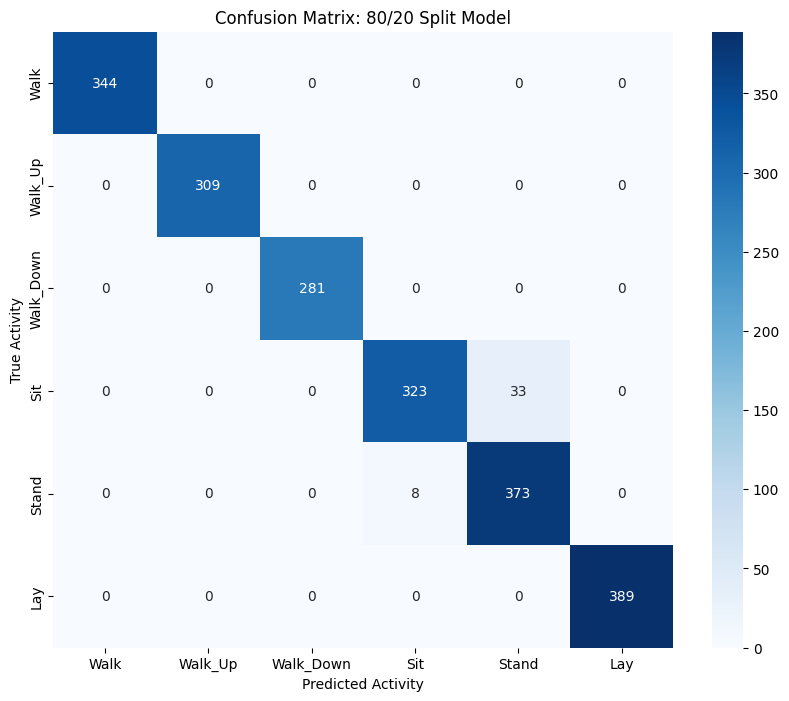

In [2]:
from sklearn.metrics import classification_report, confusion_matrix, precision_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Get predictions
y_pred_probs = model.predict(X_test_sc)
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# 2. Calculate aggregate metrics
test_loss, test_acc = model.evaluate(X_test_sc, y_test_hot, verbose=0)
precision = precision_score(y_test, y_pred_classes, average='weighted')
f1 = f1_score(y_test, y_pred_classes, average='weighted')

print(f"\n========================================")
print(f"FINAL EVALUATION METRICS (80/20 Split)")
print(f"========================================")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Precision     : {precision:.4f}")
print(f"F1-Score      : {f1:.4f}")
print(f"========================================\n")

# 3. Print Classification Report
labels = ['Walk', 'Walk_Up', 'Walk_Down', 'Sit', 'Stand', 'Lay']
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred_classes, target_names=labels))

# 4. Plot Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix: 80/20 Split Model')
plt.ylabel('True Activity')
plt.xlabel('Predicted Activity')
plt.show()